# Literature

<img src="https://www.researchgate.net/publication/301316394/figure/fig1/AS:11431281252986839@1718821248214/a-A-schematic-diagram-of-2D-Kagome-lattice-structure-with-each-unit-cell-consisting-of.jpg" alt="A Cat" width="800">

# Model

In [1]:
from topological_insulator import Problem

data_path = "../../topological_insulator/data/"
file_name = "kagome.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [2]:
location = "bulk"
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 200, # reciprocal space discretization
    location = location,
    BZ = "reduced"
)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


In [3]:
problem.model_options.solve_connectivity = True

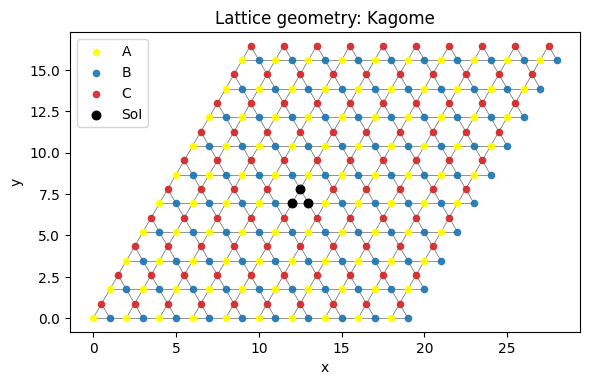

In [4]:
tb = problem.hamiltonian[location]["tight_binding"]
problem.geometry.plot_lattice(
    sites_of_interest=tb.sublattice_idxs
    )

In [8]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Bulk' eigenvalues...
'Bulk' Eigenvalues - Done!


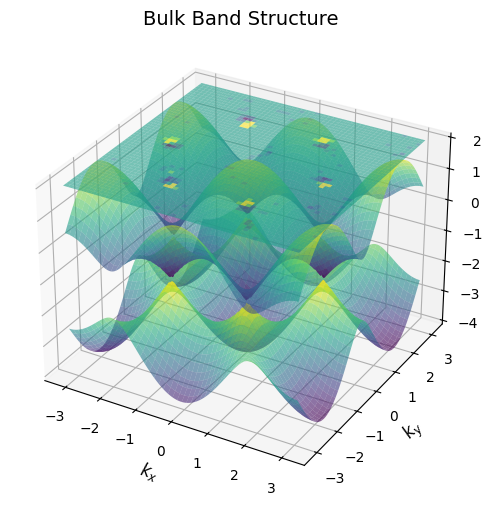

In [9]:
problem.plot(plot_type="dispersion", location=location)

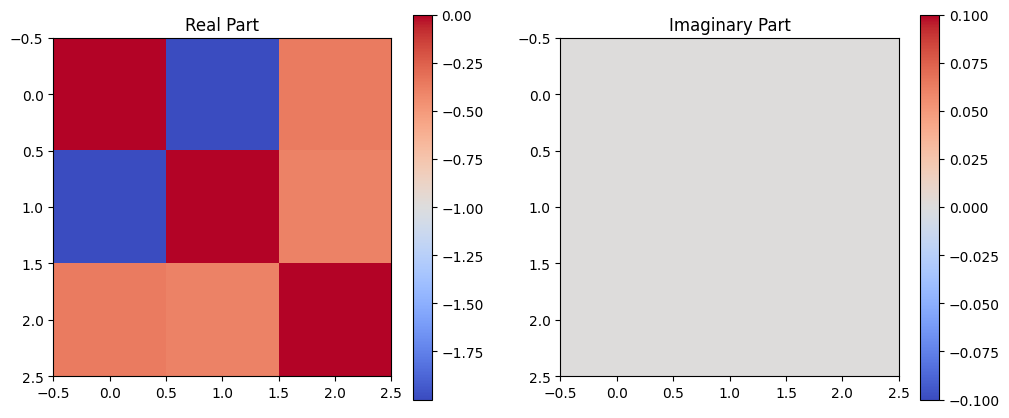

In [10]:
tb = problem.hamiltonian["bulk"]["tight_binding"]
g = problem.geometry
k_x, k_y = g.kx_bulk, g.ky_bulk
k = [k_x[g.N_k-100], k_y[g.N_k-50]]
H_k = tb._fourier_transform(g, k)

tb._visualise_matrix(H_k)